
# Supervised Deep Learning for P-Wave Arrival Picking from Z-Component Seismograms


This notebook provides a **runnable, end-to-end supervised learning workflow** for training a neural network to pick the **P-wave arrival time** from the **Z-component** of real earthquake seismograms.

The dataset is assumed to be stored in:

```python
SWAN_real_arrival.npz
```

with keys:

- `waveforms`: shape `(N, 6000, 3)`
- `P`: shape `(N,)`
- `S`: shape `(N,)`
- `ids`: shape `(N,)` (optional but recommended)

Only the **Z component** is used in this notebook.

---

## What this notebook includes

- loading `SWAN_real_arrival.npz`
- extracting the **Z-component only**
- quality control and data statistics
- visualization of waveform examples with **P arrivals marked**
- Gaussian target construction for supervised picking
- a compact **1D U-Net–style network**
- train / validation / test split with user control
- mathematical explanation of the workflow and loss
- training / validation performance curves
- test evaluation in samples and seconds
- qualitative prediction examples

---

## Problem statement

For each seismic sample, we extract the vertical trace

$$
x(t) \in \mathbb{R}, \qquad t=1,\dots,T,
$$

where here:

- $T = 6000$
- the sampling rate is **100 Hz**
- one sample corresponds to **0.01 s**

We want to learn a nonlinear mapping

$$
f_\theta : \mathbb{R}^{1 \times T} \rightarrow \mathbb{R}^{1 \times T},
$$

that outputs a **P-wave probability curve**:

$$
p_P(t) \in [0,1].
$$

The predicted P-wave arrival is then

$$
\hat{t}_P = \arg\max_t p_P(t).
$$

---

## Why use a probability curve instead of direct regression?

Instead of regressing the arrival sample index directly as a scalar, we train the network to predict a **dense target curve** centered around the true P arrival.

If the annotated P arrival is at sample $t_P$, we define a Gaussian target

$$
y_P(t) = \exp\left(-\frac{(t-t_P)^2}{2\sigma^2}\right).
$$

This makes the learning target smoother, easier to optimize, and more interpretable.  
It also resembles widely used seismic phase-picking formulations.

---

## Dataset reminder

This notebook is designed for the educational dataset **SWAN_real_arrival**, which contains:

- **100,000** samples
- **6000** time samples per waveform
- **3 components**: Z / N / E
- **100 Hz sampling rate**
- **P and S sample indices**

In this notebook, only:

$$
x_Z(t)
$$

is used as the network input.


In [1]:

# =========================
# 1. Imports and settings
# =========================
import os
import math
import random
import warnings
from dataclasses import dataclass
from typing import Optional, Tuple

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "font.size": 11,
    "axes.labelsize": 11,
    "axes.titlesize": 13,
    "legend.fontsize": 10,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.spines.top": False,
    "axes.spines.right": False,
})

SEED = 2026
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)


Using device: cuda



## User configuration

The controls below allow you to change:

- dataset path
- number of samples to use
- train / validation / test split ratios
- batch size
- learning rate
- number of epochs
- Gaussian target width
- whether to use mild amplitude augmentation

For a quick test, keep `max_samples` moderate.  
For a fuller training run, set it to `None` and use the whole dataset.


In [2]:

# =========================
# 2. User configuration
# =========================
@dataclass
class Config:
    npz_path: str = "../dataset/SWAN_real_arrival.npz"
    sampling_rate: float = 100.0
    max_samples: Optional[int] = 30000      # set to None for all samples
    train_ratio: float = 0.80
    valid_ratio: float = 0.10
    test_ratio: float = 0.10
    batch_size: int = 64
    num_workers: int = 0
    epochs: int = 12
    learning_rate: float = 1e-3
    weight_decay: float = 1e-5
    gaussian_sigma: float = 12.0
    tolerance_samples: Tuple[int, ...] = (10, 20, 50)
    use_amp_jitter: bool = True
    amp_jitter_range: Tuple[float, float] = (0.9, 1.1)
    clip_value: Optional[float] = 6.0
    save_best_model: str = "p_picker_z_only_best.pt"

cfg = Config()
print(cfg)


Config(npz_path='../dataset/SWAN_real_arrival.npz', sampling_rate=100.0, max_samples=30000, train_ratio=0.8, valid_ratio=0.1, test_ratio=0.1, batch_size=64, num_workers=0, epochs=12, learning_rate=0.001, weight_decay=1e-05, gaussian_sigma=12.0, tolerance_samples=(10, 20, 50), use_amp_jitter=True, amp_jitter_range=(0.9, 1.1), clip_value=6.0, save_best_model='p_picker_z_only_best.pt')



## Load dataset and extract the Z component

The original waveform tensor has shape

$$
(N, 6000, 3),
$$

where the last axis corresponds to:

- channel 0: Z
- channel 1: N
- channel 2: E

Here we extract only:

$$
x_Z(t) = \text{waveforms}[:, :, 0].
$$

The resulting input array has shape

$$
(N, 6000).
$$


In [3]:

# =========================
# 3. Load dataset
# =========================
assert os.path.exists(cfg.npz_path), f"File not found: {cfg.npz_path}"

data = np.load(cfg.npz_path, allow_pickle=True)
waveforms = data["waveforms"].astype(np.float32)   # (N, 6000, 3)
P_idx = data["P"].astype(np.int64)
ids = data["ids"] if "ids" in data.files else np.arange(len(waveforms)).astype(str)

print("Keys:", data.files)
print("waveforms:", waveforms.shape, waveforms.dtype)
print("P:", P_idx.shape, P_idx.dtype)
print("ids:", ids.shape)

N, T, C = waveforms.shape
assert C == 3, "Expected waveform shape (N, 6000, 3)."

valid_mask = (P_idx >= 0) & (P_idx < T)
print(f"Valid P picks: {valid_mask.sum():,} / {N:,}")

waveforms = waveforms[valid_mask]
P_idx = P_idx[valid_mask]
ids = ids[valid_mask]

Z = waveforms[:, :, 0]   # only Z component
N = len(Z)

if cfg.max_samples is not None:
    N_use = min(cfg.max_samples, N)
    rng = np.random.default_rng(SEED)
    chosen = rng.choice(N, size=N_use, replace=False)
    Z = Z[chosen]
    P_idx = P_idx[chosen]
    ids = ids[chosen]
    N = len(Z)

print("Using Z-only tensor shape:", Z.shape)
print("Using samples:", N)


Keys: ['waveforms', 'P', 'S', 'ids']
waveforms: (100000, 6000, 3) float32
P: (100000,) int64
ids: (100000,)
Valid P picks: 100,000 / 100,000
Using Z-only tensor shape: (30000, 6000)
Using samples: 30000



## Basic statistics

We first inspect:

- distribution of P-wave arrival positions
- simple amplitude statistics
- a few waveform examples

This is a useful sanity-check step before training.


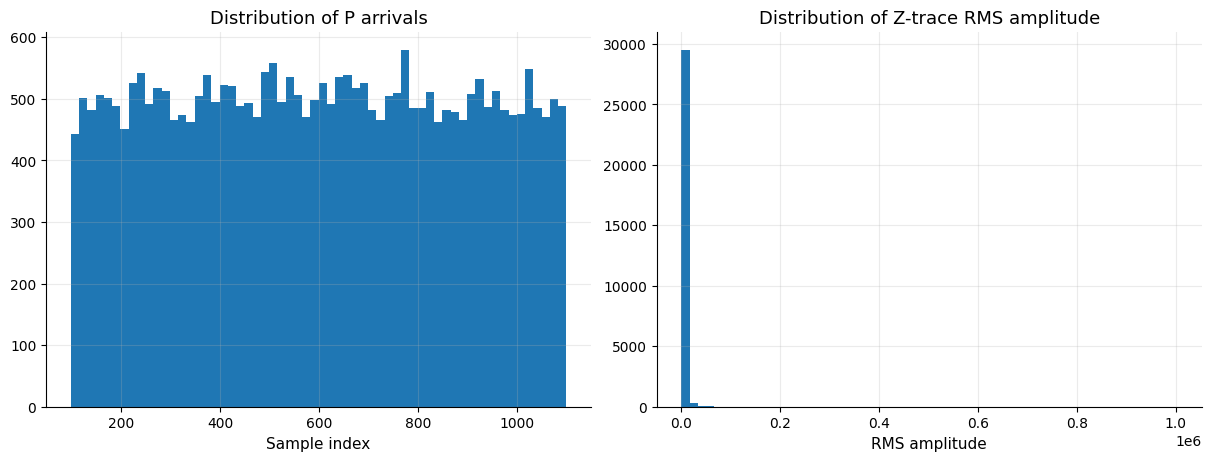

P range: 98 1099
Mean P time (s): 5.983196333333333


In [4]:

# =========================
# 4. Basic statistics
# =========================
dt = 1.0 / cfg.sampling_rate

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

axes[0].hist(P_idx, bins=60)
axes[0].set_title("Distribution of P arrivals")
axes[0].set_xlabel("Sample index")

trace_rms = np.sqrt(np.mean(Z**2, axis=1))
axes[1].hist(trace_rms, bins=60)
axes[1].set_title("Distribution of Z-trace RMS amplitude")
axes[1].set_xlabel("RMS amplitude")

plt.show()

print("P range:", P_idx.min(), P_idx.max())
print("Mean P time (s):", float(np.mean(P_idx) / cfg.sampling_rate))



## Visualize a few Z-component examples

Below we plot a few samples from the Z component only, with the true P-wave arrival marked.

This is the exact input used by the model.


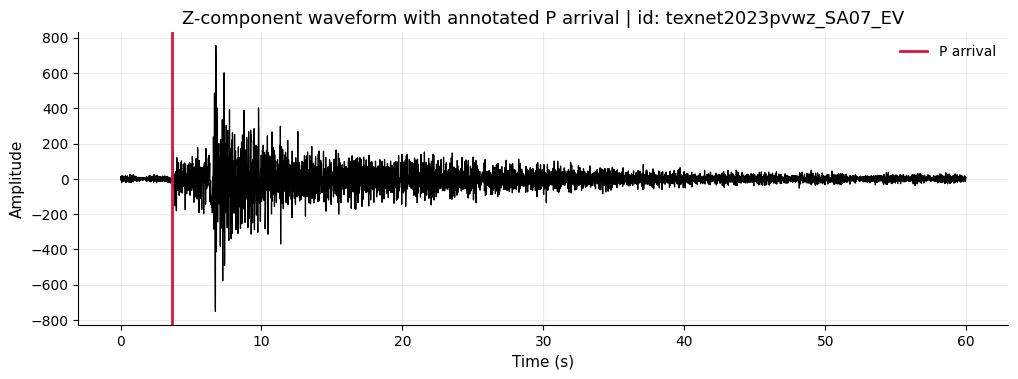

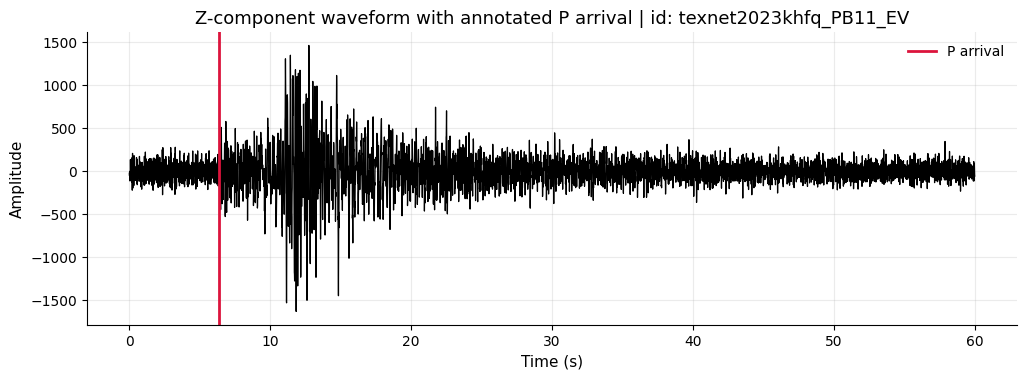

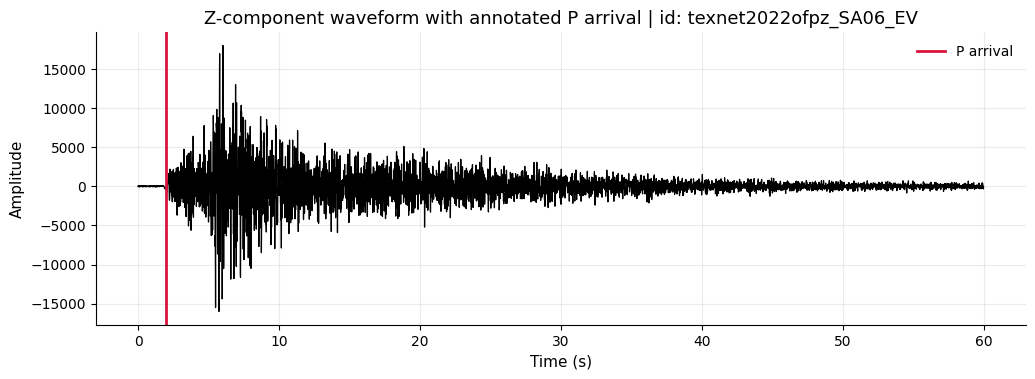

In [5]:

# =========================
# 5. Visualization helpers
# =========================
def plot_z_sample(z, p, sample_id=None, fs=100.0):
    t = np.arange(len(z)) / fs
    plt.figure(figsize=(12, 3.8))
    plt.plot(t, z, color="black", lw=0.9)
    plt.axvline(p / fs, color="crimson", lw=2.0, label="P arrival")
    plt.xlabel("Time (s)")
    plt.ylabel("Amplitude")
    title = "Z-component waveform with annotated P arrival"
    if sample_id is not None:
        title += f" | id: {sample_id}"
    plt.title(title)
    plt.legend(frameon=False)
    plt.show()

rng = np.random.default_rng(SEED)
example_ids = rng.choice(len(Z), size=3, replace=False)
for i in example_ids:
    plot_z_sample(Z[i], P_idx[i], ids[i], cfg.sampling_rate)



## Target design: Gaussian P-arrival labels

For each waveform, the supervision target is a Gaussian centered on the true P-wave arrival sample.

For a P arrival at $t_P$,

$$
y_P(t) = \exp\left(-\frac{(t-t_P)^2}{2\sigma^2}\right).
$$

This produces a smooth target curve of length $T=6000$.


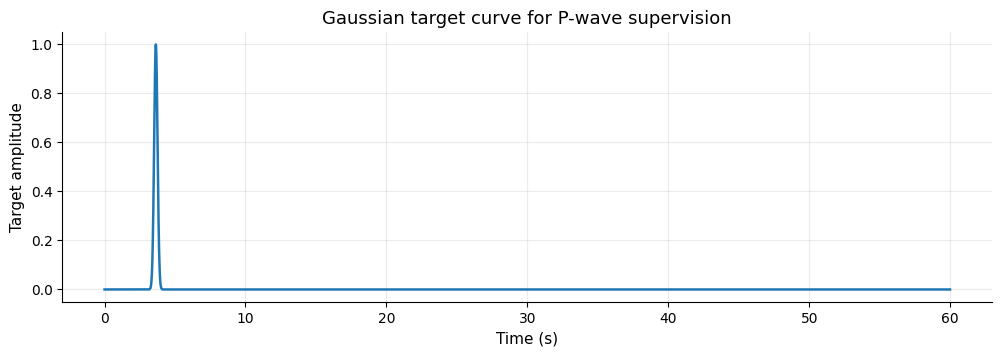

In [6]:

# =========================
# 6. Gaussian target labels
# =========================
def gaussian_pick_label(length, center, sigma):
    t = np.arange(length, dtype=np.float32)
    return np.exp(-0.5 * ((t - float(center)) / float(sigma)) ** 2).astype(np.float32)

i = example_ids[0]
target_p = gaussian_pick_label(T, P_idx[i], cfg.gaussian_sigma)
tt = np.arange(T) / cfg.sampling_rate

plt.figure(figsize=(12, 3.5))
plt.plot(tt, target_p, lw=1.8)
plt.xlabel("Time (s)")
plt.ylabel("Target amplitude")
plt.title("Gaussian target curve for P-wave supervision")
plt.show()



## Dataset class and preprocessing

Each training sample returns:

- input trace: shape `(1, T)`
- target curve: shape `(1, T)`
- discrete pick index: `p`

### Per-trace normalization

For each Z trace $x(t)$, we normalize as

$$
\tilde{x}(t) = \frac{x(t)-\mu}{\sigma+\varepsilon},
$$

where $\mu$ and $\sigma$ are the mean and standard deviation of that trace.

### Mild amplitude jitter

During training, we optionally apply a small random scaling

$$
x_{\text{aug}}(t) = a \, \tilde{x}(t), \qquad a \sim \mathcal{U}(a_{\min}, a_{\max}),
$$

to improve robustness to amplitude variability.


In [7]:

# =========================
# 7. Dataset class
# =========================
class ZPArrivalDataset(Dataset):
    def __init__(self, z_traces, p_idx, sigma=12.0, training=False, cfg=None):
        self.z_traces = z_traces.astype(np.float32)
        self.p_idx = p_idx.astype(np.int64)
        self.sigma = sigma
        self.training = training
        self.cfg = cfg

    def __len__(self):
        return len(self.z_traces)

    def _normalize(self, x):
        mu = x.mean()
        std = x.std()
        x = (x - mu) / (std + 1e-6)
        if self.cfg.clip_value is not None:
            x = np.clip(x, -self.cfg.clip_value, self.cfg.clip_value)
        return x

    def _augment(self, x):
        if self.training and self.cfg.use_amp_jitter:
            lo, hi = self.cfg.amp_jitter_range
            x = x * np.random.uniform(lo, hi)
        return x

    def __getitem__(self, idx):
        x = self.z_traces[idx].copy()   # (T,)
        p = int(self.p_idx[idx])

        x = self._normalize(x)
        x = self._augment(x)

        y = gaussian_pick_label(len(x), p, self.sigma)  # (T,)

        x = torch.from_numpy(x[None, :]).float()        # (1, T)
        y = torch.from_numpy(y[None, :]).float()        # (1, T)

        meta = {"p": torch.tensor(p, dtype=torch.long)}
        return x, y, meta



## Train / validation / test split

We partition the dataset into:

- training subset
- validation subset
- test subset

with user-controlled ratios.

If the total number of samples is $N$, then approximately

$$
N_{\text{train}} = r_{\text{train}}N,\qquad
N_{\text{valid}} = r_{\text{valid}}N,\qquad
N_{\text{test}} = r_{\text{test}}N.
$$


In [8]:

# =========================
# 8. Splits and dataloaders
# =========================
assert abs(cfg.train_ratio + cfg.valid_ratio + cfg.test_ratio - 1.0) < 1e-8

indices = np.arange(N)
rng = np.random.default_rng(SEED)
rng.shuffle(indices)

n_train = int(cfg.train_ratio * N)
n_valid = int(cfg.valid_ratio * N)
n_test = N - n_train - n_valid

idx_train = indices[:n_train]
idx_valid = indices[n_train:n_train+n_valid]
idx_test = indices[n_train+n_valid:]

train_ds = ZPArrivalDataset(Z[idx_train], P_idx[idx_train], sigma=cfg.gaussian_sigma, training=True, cfg=cfg)
valid_ds = ZPArrivalDataset(Z[idx_valid], P_idx[idx_valid], sigma=cfg.gaussian_sigma, training=False, cfg=cfg)
test_ds  = ZPArrivalDataset(Z[idx_test],  P_idx[idx_test],  sigma=cfg.gaussian_sigma, training=False, cfg=cfg)

train_loader = DataLoader(train_ds, batch_size=cfg.batch_size, shuffle=True,
                          num_workers=cfg.num_workers, pin_memory=True)
valid_loader = DataLoader(valid_ds, batch_size=cfg.batch_size, shuffle=False,
                          num_workers=cfg.num_workers, pin_memory=True)
test_loader = DataLoader(test_ds, batch_size=cfg.batch_size, shuffle=False,
                         num_workers=cfg.num_workers, pin_memory=True)

print(f"Train: {len(train_ds):,}")
print(f"Valid: {len(valid_ds):,}")
print(f"Test : {len(test_ds):,}")


Train: 24,000
Valid: 3,000
Test : 3,000



## Model architecture: 1D U-Net for Z-only P picking

Because the input is a single time series, we use **1D convolutions**.

### Input format

The network input has PyTorch shape

$$
(B, C, T) = (B, 1, 6000),
$$

where:

- $B$ is batch size
- $C=1$ because only the Z component is used
- $T=6000$ is waveform length

### Output format

The model outputs a single P-wave probability logit curve:

$$
(B, 1, 6000).
$$

After a sigmoid activation, this becomes a probability curve in $[0,1]$.


In [9]:

# =========================
# 9. Model definition
# =========================
class ConvBlock1D(nn.Module):
    def __init__(self, in_ch, out_ch, k=7, p=3):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv1d(in_ch, out_ch, kernel_size=k, padding=p),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv1d(out_ch, out_ch, kernel_size=k, padding=p),
            nn.BatchNorm1d(out_ch),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)

class UNet1DPPickerZ(nn.Module):
    def __init__(self, in_ch=1, out_ch=1, base=24):
        super().__init__()

        self.enc1 = ConvBlock1D(in_ch, base)
        self.pool1 = nn.MaxPool1d(2)

        self.enc2 = ConvBlock1D(base, base * 2)
        self.pool2 = nn.MaxPool1d(2)

        self.enc3 = ConvBlock1D(base * 2, base * 4)
        self.pool3 = nn.MaxPool1d(2)

        self.bottleneck = ConvBlock1D(base * 4, base * 8)

        self.up3 = nn.ConvTranspose1d(base * 8, base * 4, kernel_size=2, stride=2)
        self.dec3 = ConvBlock1D(base * 8, base * 4)

        self.up2 = nn.ConvTranspose1d(base * 4, base * 2, kernel_size=2, stride=2)
        self.dec2 = ConvBlock1D(base * 4, base * 2)

        self.up1 = nn.ConvTranspose1d(base * 2, base, kernel_size=2, stride=2)
        self.dec1 = ConvBlock1D(base * 2, base)

        self.head = nn.Conv1d(base, out_ch, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)                    # (B, base, 6000)
        e2 = self.enc2(self.pool1(e1))      # (B, 2*base, 3000)
        e3 = self.enc3(self.pool2(e2))      # (B, 4*base, 1500)
        b  = self.bottleneck(self.pool3(e3))# (B, 8*base, 750)

        d3 = self.up3(b)
        if d3.shape[-1] != e3.shape[-1]:
            d3 = F.interpolate(d3, size=e3.shape[-1], mode="linear", align_corners=False)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.up2(d3)
        if d2.shape[-1] != e2.shape[-1]:
            d2 = F.interpolate(d2, size=e2.shape[-1], mode="linear", align_corners=False)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        if d1.shape[-1] != e1.shape[-1]:
            d1 = F.interpolate(d1, size=e1.shape[-1], mode="linear", align_corners=False)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        logits = self.head(d1)              # (B, 1, 6000)
        return logits

model = UNet1DPPickerZ(in_ch=1, out_ch=1, base=24).to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"Trainable parameters: {n_params:,}")


UNet1DPPickerZ(
  (enc1): ConvBlock1D(
    (block): Sequential(
      (0): Conv1d(1, 24, kernel_size=(7,), stride=(1,), padding=(3,))
      (1): BatchNorm1d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv1d(24, 24, kernel_size=(7,), stride=(1,), padding=(3,))
      (4): BatchNorm1d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (enc2): ConvBlock1D(
    (block): Sequential(
      (0): Conv1d(24, 48, kernel_size=(7,), stride=(1,), padding=(3,))
      (1): BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv1d(48, 48, kernel_size=(7,), stride=(1,), padding=(3,))
      (4): BatchNorm1d(48, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
    )
  )
  (pool2): MaxP


## Loss function

Let the network output logits $\mathbf{z}$ and probabilities

$$
\hat{\mathbf{y}} = \sigma(\mathbf{z}),
$$

where $\sigma$ is the sigmoid function.

We combine:

1. **binary cross-entropy with logits**
2. **soft Dice loss**

### Binary cross-entropy

$$
\mathcal{L}_{\text{BCE}}
=
-\frac{1}{T}
\sum_{t=1}^{T}
\left[
y_t \log \hat{y}_t + (1-y_t)\log(1-\hat{y}_t)
\right].
$$

### Soft Dice loss

$$
\mathrm{Dice}
=
\frac{2\sum_t \hat{y}_t y_t + \epsilon}
{\sum_t \hat{y}_t + \sum_t y_t + \epsilon},
$$

$$
\mathcal{L}_{\text{Dice}} = 1 - \mathrm{Dice}.
$$

### Total loss

$$
\mathcal{L}
=
\lambda_{\text{BCE}}\mathcal{L}_{\text{BCE}}
+
\lambda_{\text{Dice}}\mathcal{L}_{\text{Dice}}.
$$

This combination works well because BCE gives local supervision while Dice emphasizes overlap of the predicted peak with the target peak.


In [10]:

# =========================
# 10. Loss and metrics
# =========================
class BCEDiceLoss(nn.Module):
    def __init__(self, bce_weight=1.0, dice_weight=1.0, eps=1e-6):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss()
        self.bce_weight = bce_weight
        self.dice_weight = dice_weight
        self.eps = eps

    def forward(self, logits, target):
        bce = self.bce(logits, target)

        prob = torch.sigmoid(logits)
        inter = (prob * target).sum(dim=-1)
        denom = prob.sum(dim=-1) + target.sum(dim=-1)
        dice = (2.0 * inter + self.eps) / (denom + self.eps)
        dice_loss = 1.0 - dice.mean()

        total = self.bce_weight * bce + self.dice_weight * dice_loss
        return total, {"bce": bce.item(), "dice": dice_loss.item()}

criterion = BCEDiceLoss()

@torch.no_grad()
def picks_from_logits(logits):
    prob = torch.sigmoid(logits)         # (B, 1, T)
    p_pred = prob[:, 0, :].argmax(dim=-1)
    return p_pred, prob

@torch.no_grad()
def batch_metrics(logits, meta, fs, tolerances=(10, 20, 50)):
    p_true = meta["p"].to(logits.device)
    p_pred, _ = picks_from_logits(logits)
    p_err = (p_pred - p_true).abs().float()

    metrics = {
        "p_mae_samples": p_err.mean().item(),
        "p_mae_seconds": (p_err / fs).mean().item(),
    }
    for tol in tolerances:
        metrics[f"p_acc@{tol}"] = (p_err <= tol).float().mean().item()
    return metrics



## Training setup and practical tricks

A few simple but effective training tricks are used here:

- **per-trace normalization**
- **mild amplitude jitter**
- **gradient clipping**
- **learning-rate reduction on plateau**
- **best-model checkpointing using validation loss**

These improve optimization stability and generalization without making the notebook overly complicated.


In [11]:

# =========================
# 11. Optimizer and loops
# =========================
optimizer = torch.optim.Adam(model.parameters(), lr=cfg.learning_rate, weight_decay=cfg.weight_decay)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=2)

def merge_metric_dicts(metric_list):
    out = {}
    keys = metric_list[0].keys()
    for k in keys:
        out[k] = float(np.mean([m[k] for m in metric_list]))
    return out

def run_one_epoch(model, loader, optimizer=None):
    is_train = optimizer is not None
    model.train(is_train)

    loss_list = []
    metric_list = []

    for x, y, meta in loader:
        x = x.to(DEVICE, non_blocking=True)       # (B, 1, T)
        y = y.to(DEVICE, non_blocking=True)       # (B, 1, T)
        meta = {k: v.to(DEVICE) for k, v in meta.items()}

        logits = model(x)
        loss, extra = criterion(logits, y)

        if is_train:
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
            optimizer.step()

        loss_list.append({
            "loss": loss.item(),
            "bce": extra["bce"],
            "dice": extra["dice"],
        })
        metric_list.append(batch_metrics(logits, meta, cfg.sampling_rate, cfg.tolerance_samples))

    return merge_metric_dicts(loss_list), merge_metric_dicts(metric_list)

history = {
    "train_loss": [], "valid_loss": [],
    "train_p_mae": [], "valid_p_mae": [],
}

best_val = np.inf
best_epoch = -1



## Train the P-picker model


In [12]:

# =========================
# 12. Training
# =========================
for epoch in range(1, cfg.epochs + 1):
    train_loss_dict, train_metric_dict = run_one_epoch(model, train_loader, optimizer=optimizer)
    valid_loss_dict, valid_metric_dict = run_one_epoch(model, valid_loader, optimizer=None)

    scheduler.step(valid_loss_dict["loss"])

    history["train_loss"].append(train_loss_dict["loss"])
    history["valid_loss"].append(valid_loss_dict["loss"])
    history["train_p_mae"].append(train_metric_dict["p_mae_samples"])
    history["valid_p_mae"].append(valid_metric_dict["p_mae_samples"])

    print(
        f"Epoch {epoch:02d}/{cfg.epochs} | "
        f"train loss={train_loss_dict['loss']:.4f}, val loss={valid_loss_dict['loss']:.4f} | "
        f"P-MAE={valid_metric_dict['p_mae_samples']:.2f} samples "
        f"({valid_metric_dict['p_mae_seconds']:.3f} s)"
    )

    if valid_loss_dict["loss"] < best_val:
        best_val = valid_loss_dict["loss"]
        best_epoch = epoch
        torch.save(model.state_dict(), cfg.save_best_model)

print(f"Best validation loss: {best_val:.5f} at epoch {best_epoch}")


Epoch 01/12 | train loss=1.1407, val loss=0.8358 | P-MAE=548.00 samples (5.480 s)
Epoch 02/12 | train loss=0.5951, val loss=0.7875 | P-MAE=457.99 samples (4.580 s)
Epoch 03/12 | train loss=0.5045, val loss=0.6979 | P-MAE=317.82 samples (3.178 s)
Epoch 04/12 | train loss=0.4874, val loss=0.4833 | P-MAE=244.81 samples (2.448 s)
Epoch 05/12 | train loss=0.4808, val loss=0.5272 | P-MAE=256.82 samples (2.568 s)
Epoch 06/12 | train loss=0.4770, val loss=0.4774 | P-MAE=214.27 samples (2.143 s)
Epoch 07/12 | train loss=0.4738, val loss=0.4755 | P-MAE=222.35 samples (2.223 s)
Epoch 08/12 | train loss=0.4705, val loss=0.4950 | P-MAE=244.99 samples (2.450 s)
Epoch 09/12 | train loss=0.4681, val loss=0.4790 | P-MAE=251.11 samples (2.511 s)
Epoch 10/12 | train loss=0.4639, val loss=0.4728 | P-MAE=230.02 samples (2.300 s)
Epoch 11/12 | train loss=0.4635, val loss=0.4728 | P-MAE=226.23 samples (2.262 s)
Epoch 12/12 | train loss=0.4614, val loss=0.4760 | P-MAE=204.04 samples (2.040 s)
Best validation 


## Learning curves

We visualize:

- training and validation loss
- training and validation P-pick MAE

These curves help assess convergence and overfitting.


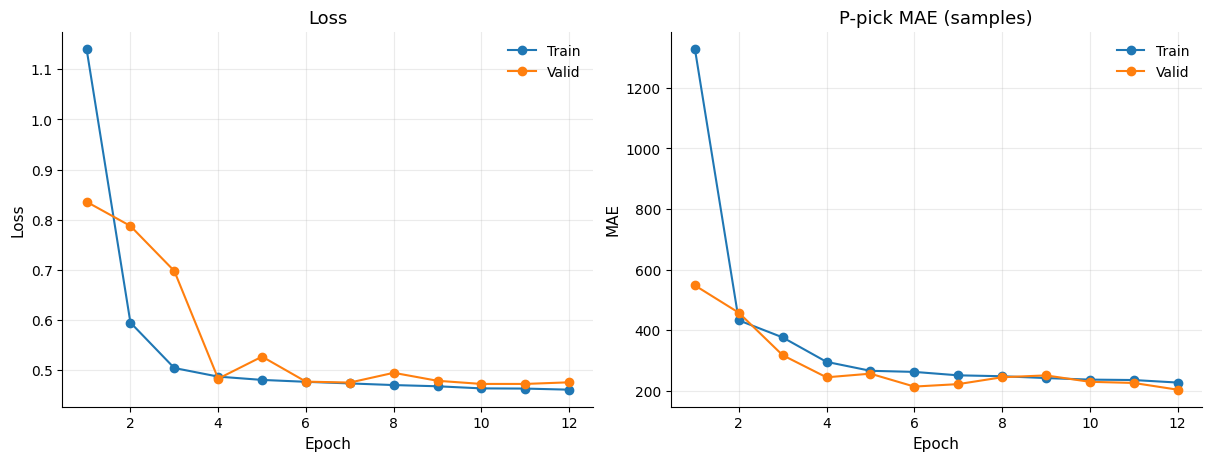

In [13]:

# =========================
# 13. Learning curves
# =========================
epochs = np.arange(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5), constrained_layout=True)

axes[0].plot(epochs, history["train_loss"], marker="o", label="Train")
axes[0].plot(epochs, history["valid_loss"], marker="o", label="Valid")
axes[0].set_title("Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend(frameon=False)

axes[1].plot(epochs, history["train_p_mae"], marker="o", label="Train")
axes[1].plot(epochs, history["valid_p_mae"], marker="o", label="Valid")
axes[1].set_title("P-pick MAE (samples)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("MAE")
axes[1].legend(frameon=False)

plt.show()



## Test evaluation

We reload the best validation model and evaluate it on the held-out test set.

Reported metrics include:

- mean absolute error in samples
- mean absolute error in seconds
- accuracy within several tolerance windows


In [14]:

# =========================
# 14. Test evaluation
# =========================
best_model = UNet1DPPickerZ(in_ch=1, out_ch=1, base=24).to(DEVICE)
best_model.load_state_dict(torch.load(cfg.save_best_model, map_location=DEVICE))
best_model.eval()

test_loss_dict, test_metric_dict = run_one_epoch(best_model, test_loader, optimizer=None)

print("Test loss metrics:")
for k, v in test_loss_dict.items():
    print(f"  {k:>12s}: {v:.6f}")

print("\nTest P-pick metrics:")
for k, v in test_metric_dict.items():
    if "acc@" in k:
        print(f"  {k:>12s}: {100*v:.2f}%")
    else:
        print(f"  {k:>12s}: {v:.6f}")


Test loss metrics:
          loss: 0.467247
           bce: 0.022767
          dice: 0.444479

Test P-pick metrics:
  p_mae_samples: 253.771657
  p_mae_seconds: 2.537717
      p_acc@10: 68.16%
      p_acc@20: 78.39%
      p_acc@50: 83.08%



## Qualitative prediction examples

Below we show a few test examples with:

- the Z-component waveform
- the true P-wave arrival
- the predicted P-wave arrival
- the predicted P-wave probability curve


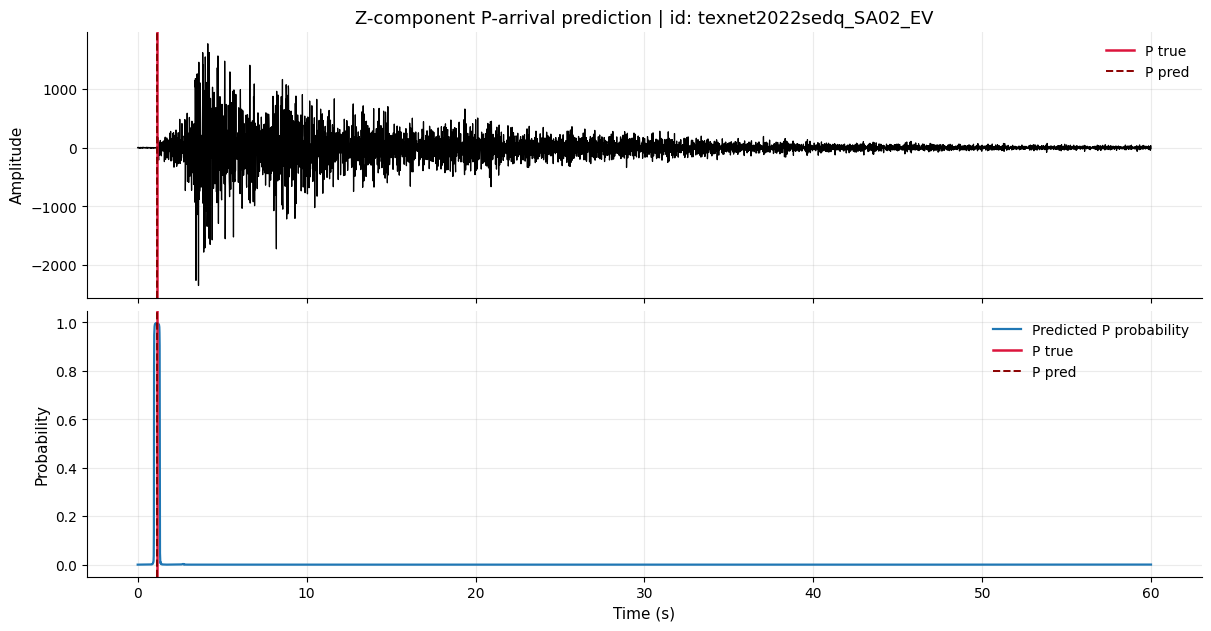

id=texnet2022sedq_SA02_EV
  P true= 117, P pred= 113, abs err=   4 samples (0.040 s)


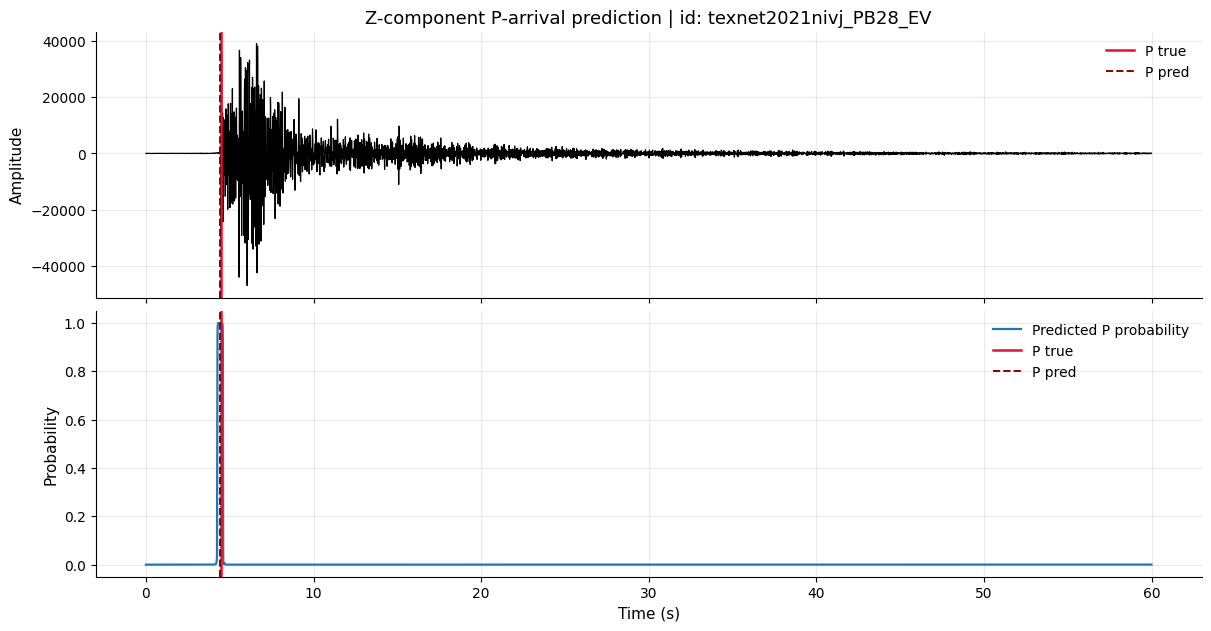

id=texnet2021nivj_PB28_EV
  P true= 445, P pred= 442, abs err=   3 samples (0.030 s)


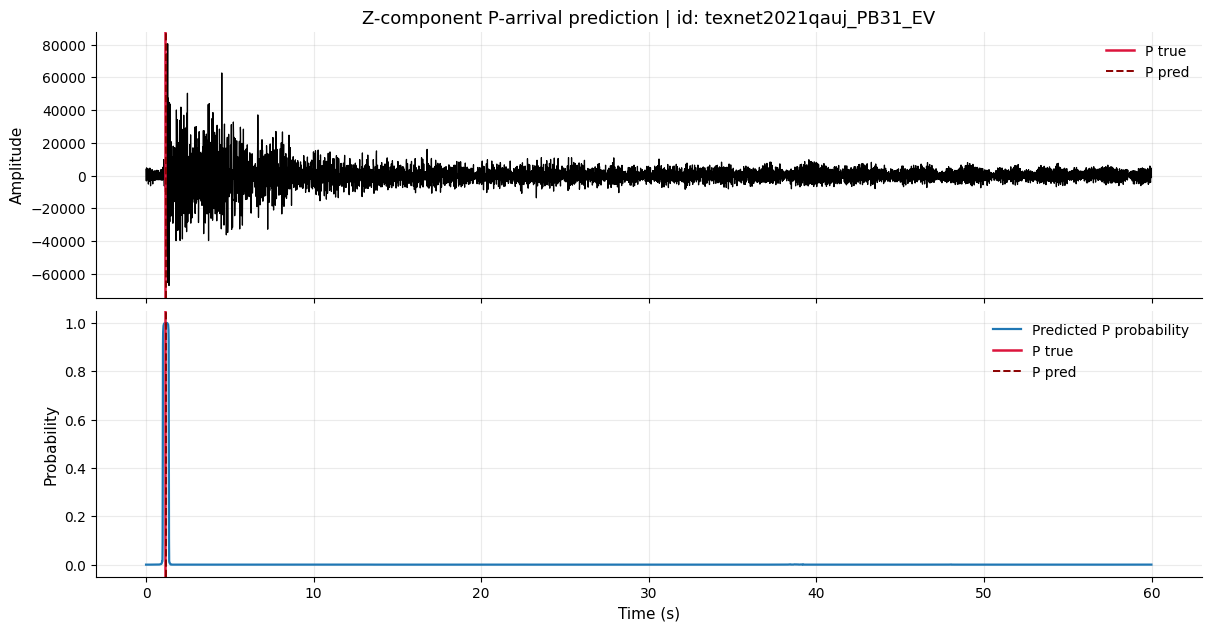

id=texnet2021qauj_PB31_EV
  P true= 111, P pred= 118, abs err=   7 samples (0.070 s)


In [15]:

# =========================
# 15. Prediction visualization
# =========================
@torch.no_grad()
def predict_one(model, z_np):
    x = z_np.copy().astype(np.float32)
    mu = x.mean()
    std = x.std()
    x = (x - mu) / (std + 1e-6)
    if cfg.clip_value is not None:
        x = np.clip(x, -cfg.clip_value, cfg.clip_value)

    xt = torch.from_numpy(x[None, None, :]).float().to(DEVICE)  # (1,1,T)
    logits = model(xt)
    p_pred, prob = picks_from_logits(logits)
    return int(p_pred[0].cpu().item()), prob[0, 0].cpu().numpy()

def plot_prediction_example(z, p_true, p_pred, prob, fs=100.0, sample_id=None):
    t = np.arange(len(z)) / fs

    fig, axes = plt.subplots(2, 1, figsize=(12, 6.2), sharex=True, constrained_layout=True)

    axes[0].plot(t, z, color="black", lw=0.9)
    axes[0].axvline(p_true / fs, color="crimson", lw=1.8, label="P true")
    axes[0].axvline(p_pred / fs, color="darkred", lw=1.4, ls="--", label="P pred")
    axes[0].set_ylabel("Amplitude")
    title = "Z-component P-arrival prediction"
    if sample_id is not None:
        title += f" | id: {sample_id}"
    axes[0].set_title(title)
    axes[0].legend(frameon=False)

    axes[1].plot(t, prob, lw=1.6, label="Predicted P probability")
    axes[1].axvline(p_true / fs, color="crimson", lw=1.8, label="P true")
    axes[1].axvline(p_pred / fs, color="darkred", lw=1.4, ls="--", label="P pred")
    axes[1].set_xlabel("Time (s)")
    axes[1].set_ylabel("Probability")
    axes[1].legend(frameon=False)

    plt.show()

rng = np.random.default_rng(SEED + 1)
show_n = min(3, len(idx_test))
picked = rng.choice(len(idx_test), size=show_n, replace=False)

for j in picked:
    real_idx = idx_test[j]
    z = Z[real_idx]
    p_true = int(P_idx[real_idx])
    sample_id = ids[real_idx]
    p_pred, prob = predict_one(best_model, z)
    plot_prediction_example(z, p_true, p_pred, prob, cfg.sampling_rate, sample_id)

    print(f"id={sample_id}")
    print(f"  P true={p_true:4d}, P pred={p_pred:4d}, abs err={abs(p_pred-p_true):4d} samples ({abs(p_pred-p_true)/cfg.sampling_rate:.3f} s)")



## Architecture summary

This Z-only P-picker uses the same general strategy as the multi-component notebook, but simplifies the problem to a single channel and a single target.

### Input format

PyTorch tensor shape:

$$
(B, 1, 6000)
$$

### Intermediate tensor sizes

With `base=24`, the principal feature sizes are:

- input: `(B, 1, 6000)`
- encoder 1: `(B, 24, 6000)`
- pool 1: `(B, 24, 3000)`
- encoder 2: `(B, 48, 3000)`
- pool 2: `(B, 48, 1500)`
- encoder 3: `(B, 96, 1500)`
- pool 3: `(B, 96, 750)`
- bottleneck: `(B, 192, 750)`
- decoder 3 output: `(B, 96, 1500)`
- decoder 2 output: `(B, 48, 3000)`
- decoder 1 output: `(B, 24, 6000)`
- final output logits: `(B, 1, 6000)`

### Output format

After sigmoid, the output is a P-wave probability curve:

$$
(B, 1, 6000).
$$

The final pick is computed by

$$
\hat{t}_P = \arg\max_t p_P(t).
$$



## Homework?

A few natural next steps are:

1. compare **Z-only** picking against **3-component** picking,
2. test a direct regression model for the P index,
3. add bandpass augmentation or additive noise augmentation,
4. try a residual 1D U-Net or transformer encoder,
5. study performance versus SNR or versus P-arrival position.

---

## Brief Conclusion

This notebook provides a complete supervised baseline for **P-wave arrival picking from the Z component alone** using `SWAN_real_arrival.npz`.
